In [1]:
#importing required libraries for data cleaning, text cleaning, and visualiztion 
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the raw starbucks review dataset
df = pd.read_csv("starbucks_reviews_sample_15000.csv")
#checking full structure of data
df

,review_id,stars,date,text
0,ULzbgT5SPThiMOoo4a_Adw,2.0,2017-12-29 19:38:31,"Ordered Caramel frappe at Drive thru, BIG MIST..."
1,RXqhxbAuPPSNs-oyJJyOgw,4.0,2014-02-05 19:38:24,Drum-roll please! Review #100 coming right up!...
2,LuMkMBAUV1B-2dm2pqSBWw,4.0,2017-02-09 04:35:39,We stopped here for my Chai and Hubby's coffee...
3,oP9FdA8uUJXGwP-1xYL8eA,4.0,2018-02-13 15:35:28,This is a pretty good Starbucks. It is in a gr...
4,NoPOfj7gC1l48dC0XH7Spw,1.0,2016-01-30 01:10:42,"I went in when they had 4 people working, wait..."
...,...,...,...,...
14995,Bi7ZuSQ1eI4GwFuEtqKGLg,5.0,2021-10-07 18:41:06,"We came in to get two drinks, they made my fla..."
14996,9lAa6Kc9zWEoFdklC0Wh5w,4.0,2017-01-22 16:55:30,Stand alone Starbucks located outside the trav...
14997,jDiiP2AJO9_iBF16lr4dEQ,4.0,2015-01-04 02:37:17,This place is tiny ;( I entered with a small/c...
14998,DYLZvRqreWfdasBCm2x4sA,5.0,2015-07-03 13:29:09,"Today I came in for the oatmeal. Over all, it'..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   review_id  15000 non-null  object 
 1   stars      15000 non-null  float64
 2   date       15000 non-null  object 
 3   text       15000 non-null  object 
dtypes: float64(1), object(3)
memory usage: 468.9+ KB


In [4]:
#cheking null or missing values
df.isnull().sum()

review_id    0
stars        0
date         0
text         0
dtype: int64

In [5]:
#cheking for duplicates in review_id
df.duplicated('review_id').sum()

np.int64(0)

In [6]:
# Create a 'error_reading' of the rows that look like #NAME? in Excel (Excel was not able to read review_id starting with '-' so it displays #NAME?)
error_reading = df[df['review_id'].str.startswith('-', na=False)]

#inspecting rows that look like #NAME? in Excel
print(error_reading)

                    review_id  stars                 date  \
69     -MZXc3ivSomsmEYZ_ziA6A    3.0  2011-04-26 02:56:26   
222    -VwhqYckdkrSWX75lq0o2w    2.0  2016-04-15 03:53:05   
238    -6VTQhfaQw4Cy-gIsZWYqA    1.0  2014-10-30 20:04:28   
252    -752B6AQNwRASSg21V7-Cg    1.0  2016-02-28 16:48:57   
255    -Dc3Uu_LboVnbbKKh6l7tQ    5.0  2017-07-13 14:00:42   
...                       ...    ...                  ...   
14851  -MHeLEq3ANicFoErndvuNg    1.0  2019-07-13 02:57:04   
14859  -Q6I5cPjba1V4O4HpWhrTg    3.0  2015-01-07 18:31:58   
14874  -JGlX_rSGn9FN3gVoSeJNw    1.0  2017-09-09 02:13:28   
14914  -owT0EHLcuoDkx03o4A3IA    1.0  2020-09-18 20:09:26   
14991  -swuDyDYu6WFhpDto2ywjQ    5.0  2021-12-15 21:06:08   

                                                    text  
69     Obviously it's starbucks and obviously their p...  
222    Drinks are decent, but expensive. Not many out...  
238    I don't make reviews often but I had to today ...  
252    This is the most ineffic

In [7]:
# Checking how many rows currently are starting with '-'
error_reading_before = df[df['review_id'].str.startswith('-', na=False)]
print(f"Rows found before cleaning: {len(error_reading_before)}")

Rows found before cleaning: 246


In [8]:
# Removing the leading '-' from the review_id column to prevent Excel #NAME? errors
df['review_id'] = df['review_id'].str.lstrip('-')

In [9]:
# Verifying that no 'review_id' still start with '-' (this will ensures Excel won't show #NAME? errors)
error_reading_after = df[df['review_id'].str.startswith('-', na=False)]
print(f"Number of problematic IDs remaining: {len(error_reading_after)}")

if len(error_reading_after) == 0:
    print("Verification Success: All leading dashes removed")

Number of problematic IDs remaining: 0
Verification Success: All leading dashes removed


In [10]:
#cheking for duplicates in review_id one more time to make sure everything
df.duplicated('review_id').sum()

np.int64(0)

In [11]:
# Create a full independent copy of the dataframe to avoid SettingWithCopyWarning
df = df.copy()

In [12]:
# 3. Converting stars from float to integer data type
df['stars'] = df['stars'].astype(int)

In [13]:
#checking if the data type chnaged to int
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review_id  15000 non-null  object
 1   stars      15000 non-null  int64 
 2   date       15000 non-null  object
 3   text       15000 non-null  object
dtypes: int64(1), object(3)
memory usage: 468.9+ KB


In [14]:
#converting "date" column data typye object into datetime fromat datatypye
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [15]:
#checking if the data type chnaged to dateime
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   review_id  15000 non-null  object        
 1   stars      15000 non-null  int64         
 2   date       15000 non-null  datetime64[ns]
 3   text       15000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 468.9+ KB


In [16]:
#creating new column "year_month" from "date" column
df["year_month"] = df["date"].dt.to_period("M")

In [17]:
#Displaying the updated dataframe to inspect the new added column
df

,review_id,stars,date,text,year_month
0,ULzbgT5SPThiMOoo4a_Adw,2,2017-12-29 19:38:31,"Ordered Caramel frappe at Drive thru, BIG MIST...",2017-12
1,RXqhxbAuPPSNs-oyJJyOgw,4,2014-02-05 19:38:24,Drum-roll please! Review #100 coming right up!...,2014-02
2,LuMkMBAUV1B-2dm2pqSBWw,4,2017-02-09 04:35:39,We stopped here for my Chai and Hubby's coffee...,2017-02
3,oP9FdA8uUJXGwP-1xYL8eA,4,2018-02-13 15:35:28,This is a pretty good Starbucks. It is in a gr...,2018-02
4,NoPOfj7gC1l48dC0XH7Spw,1,2016-01-30 01:10:42,"I went in when they had 4 people working, wait...",2016-01
...,...,...,...,...,...
14995,Bi7ZuSQ1eI4GwFuEtqKGLg,5,2021-10-07 18:41:06,"We came in to get two drinks, they made my fla...",2021-10
14996,9lAa6Kc9zWEoFdklC0Wh5w,4,2017-01-22 16:55:30,Stand alone Starbucks located outside the trav...,2017-01
14997,jDiiP2AJO9_iBF16lr4dEQ,4,2015-01-04 02:37:17,This place is tiny ;( I entered with a small/c...,2015-01
14998,DYLZvRqreWfdasBCm2x4sA,5,2015-07-03 13:29:09,"Today I came in for the oatmeal. Over all, it'...",2015-07


In [18]:
#Verifying data type of new added column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   review_id   15000 non-null  object        
 1   stars       15000 non-null  int64         
 2   date        15000 non-null  datetime64[ns]
 3   text        15000 non-null  object        
 4   year_month  15000 non-null  period[M]     
dtypes: datetime64[ns](1), int64(1), object(2), period[M](1)
memory usage: 586.1+ KB


In [19]:
#installing language detection liabrary to filter non-english reviews 
!pip install langdetect

In [20]:
#importing the tools and defining the english only rule
from langdetect import detect

def is_english(text):
    try:
        #Return True if the language is english ('en')
        return detect(text) == "en"
    except:
        #Return False if the text is unreadable
        return False

In [22]:
#Applying language detection and creating temporary new column
df["is_english"] = df["text"].apply(is_english)

In [23]:
#Checking the count of Englsih vs non-English reviews
df["is_english"].value_counts()

is_english
True     14993
False        7
Name: count, dtype: int64

In [24]:
#Inspecting non-English rows and selecting specific columns for review
df[df["is_english"] == False][["review_id","text"]]

,review_id,text
1163,VjFh5AabPdLR59pOzCvKxA,no. no. no. no. no. no. no. no. no. no. no. no...
1886,lpeoR3iM2SsKoIaUpkbL_g,应该是所有住delmar的Wash U的留学生必去的地方了，国际连锁，大多东西都是标准化，即...
3142,3lSQr_tRry9Q8x2eg4z1Gg,Vivian ist meine Lieblingsmitarbeiterin! Sie i...
8334,pqLaB2pz5EvmrG9Xcm1mMw,"Es el peor Starbucks que haya estado,siempre l..."
12961,tyj8pLqPqV8KtN1eEvgWQ,Questo Starbucks è proprio carino e degno di n...
13924,gfD7_Qedwpwbevy17Y_yWg,"Leider sehr dreckig, Personal total überforder..."
14975,U8LW7DQeucB6BnJhceMrig,Diese befindet sich direkt hintern Eingang zum...


In [25]:
#Filtering and keeping only the english reviews and droping the rest
df = df[df["is_english"] == True].copy()

In [26]:
#Removing the temporary language check column
df = df.drop(columns=["is_english"])

In [27]:
#Verifying the row count and column structure to see if it dropped the temporary "is_english" column
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14993 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   review_id   14993 non-null  object        
 1   stars       14993 non-null  int64         
 2   date        14993 non-null  datetime64[ns]
 3   text        14993 non-null  object        
 4   year_month  14993 non-null  period[M]     
dtypes: datetime64[ns](1), int64(1), object(2), period[M](1)
memory usage: 702.8+ KB


In [28]:
#Calculating length of the original raw text from "text" column
df["raw_text_length"] = df["text"].str.len()

In [29]:
#Displaying the first 5 rows to verify the 'text_length' column was created correctly
df.head(5)

,review_id,stars,date,text,year_month,raw_text_length
0,ULzbgT5SPThiMOoo4a_Adw,2,2017-12-29 19:38:31,"Ordered Caramel frappe at Drive thru, BIG MIST...",2017-12,105
1,RXqhxbAuPPSNs-oyJJyOgw,4,2014-02-05 19:38:24,Drum-roll please! Review #100 coming right up!...,2014-02,920
2,LuMkMBAUV1B-2dm2pqSBWw,4,2017-02-09 04:35:39,We stopped here for my Chai and Hubby's coffee...,2017-02,405
3,oP9FdA8uUJXGwP-1xYL8eA,4,2018-02-13 15:35:28,This is a pretty good Starbucks. It is in a gr...,2018-02,438
4,NoPOfj7gC1l48dC0XH7Spw,1,2016-01-30 01:10:42,"I went in when they had 4 people working, wait...",2016-01,370


In [31]:
#Filtering out short reviews to ensure sufficient text data for Sentiment and Theme extraction
df = df[df["raw_text_length"] >= 20].copy()

In [32]:
#Verifying the number of rows remaining after filtering out short reviews
df.shape

(14992, 6)

In [33]:
#Function to transform raw text into a clean format for Machine Learning
def clean_text(text):
    text = str(text).lower()                    #Convert to lowercase 
    text = re.sub(r"http\S+|www\S+", "", text)  #Remove URLs if there is any
    text = re.sub(r"[^a-z\s]", " ", text)      #Keep only letters (removes punctuation/numbers)
    text = re.sub(r"\s+", " ", text).strip()   #Remove extra whitespace and leading/trailing spaces
    return text

#Applying the cleaning function to create a specialized column "clean_text" for ML models
df["clean_text"] = df["text"].apply(clean_text)

In [34]:
#Verifying text cleaning results by displaying first 5 rows
df.head(5)

,review_id,stars,date,text,year_month,raw_text_length,clean_text
0,ULzbgT5SPThiMOoo4a_Adw,2,2017-12-29 19:38:31,"Ordered Caramel frappe at Drive thru, BIG MIST...",2017-12,105,ordered caramel frappe at drive thru big mista...
1,RXqhxbAuPPSNs-oyJJyOgw,4,2014-02-05 19:38:24,Drum-roll please! Review #100 coming right up!...,2014-02,920,drum roll please review coming right up i chos...
2,LuMkMBAUV1B-2dm2pqSBWw,4,2017-02-09 04:35:39,We stopped here for my Chai and Hubby's coffee...,2017-02,405,we stopped here for my chai and hubby s coffee...
3,oP9FdA8uUJXGwP-1xYL8eA,4,2018-02-13 15:35:28,This is a pretty good Starbucks. It is in a gr...,2018-02,438,this is a pretty good starbucks it is in a gre...
4,NoPOfj7gC1l48dC0XH7Spw,1,2016-01-30 01:10:42,"I went in when they had 4 people working, wait...",2016-01,370,i went in when they had people working waited ...


In [36]:
#Renaming columns for clarity and consistency
df = df.rename(columns={"text": "raw_text"})

In [37]:
df.head(5)

,review_id,stars,date,raw_text,year_month,raw_text_length,clean_text
0,ULzbgT5SPThiMOoo4a_Adw,2,2017-12-29 19:38:31,"Ordered Caramel frappe at Drive thru, BIG MIST...",2017-12,105,ordered caramel frappe at drive thru big mista...
1,RXqhxbAuPPSNs-oyJJyOgw,4,2014-02-05 19:38:24,Drum-roll please! Review #100 coming right up!...,2014-02,920,drum roll please review coming right up i chos...
2,LuMkMBAUV1B-2dm2pqSBWw,4,2017-02-09 04:35:39,We stopped here for my Chai and Hubby's coffee...,2017-02,405,we stopped here for my chai and hubby s coffee...
3,oP9FdA8uUJXGwP-1xYL8eA,4,2018-02-13 15:35:28,This is a pretty good Starbucks. It is in a gr...,2018-02,438,this is a pretty good starbucks it is in a gre...
4,NoPOfj7gC1l48dC0XH7Spw,1,2016-01-30 01:10:42,"I went in when they had 4 people working, wait...",2016-01,370,i went in when they had people working waited ...


In [38]:
# Rearranging columns for a more logical workflow
df = df[
    [
        "review_id",
        "stars",
        "date",
        "year_month",
        "raw_text",
        "clean_text",
        "raw_text_length"
    ]
]

In [39]:
df.head(5)

,review_id,stars,date,year_month,raw_text,clean_text,raw_text_length
0,ULzbgT5SPThiMOoo4a_Adw,2,2017-12-29 19:38:31,2017-12,"Ordered Caramel frappe at Drive thru, BIG MIST...",ordered caramel frappe at drive thru big mista...,105
1,RXqhxbAuPPSNs-oyJJyOgw,4,2014-02-05 19:38:24,2014-02,Drum-roll please! Review #100 coming right up!...,drum roll please review coming right up i chos...,920
2,LuMkMBAUV1B-2dm2pqSBWw,4,2017-02-09 04:35:39,2017-02,We stopped here for my Chai and Hubby's coffee...,we stopped here for my chai and hubby s coffee...,405
3,oP9FdA8uUJXGwP-1xYL8eA,4,2018-02-13 15:35:28,2018-02,This is a pretty good Starbucks. It is in a gr...,this is a pretty good starbucks it is in a gre...,438
4,NoPOfj7gC1l48dC0XH7Spw,1,2016-01-30 01:10:42,2016-01,"I went in when they had 4 people working, wait...",i went in when they had people working waited ...,370


In [40]:
# Saving the cleaned data
df.to_csv("final_cleaned_starbucks_reviews.csv", index=False)

# visualizations

In [41]:
# Setting the visual style for all plots
sns.set_style("whitegrid")

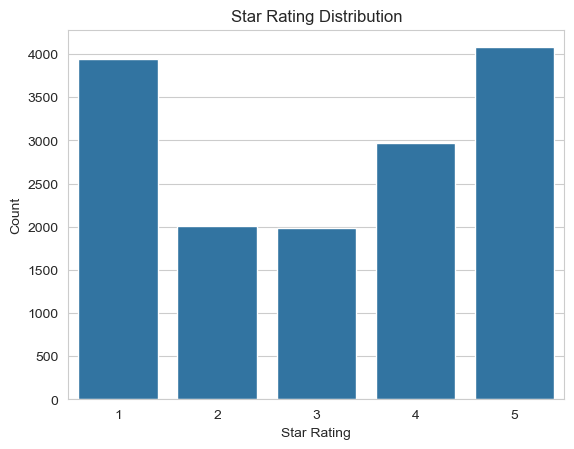

In [42]:
#checking star rating distribution 
plt.figure()
sns.countplot(x="stars", data=df)
plt.title("Star Rating Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.show()

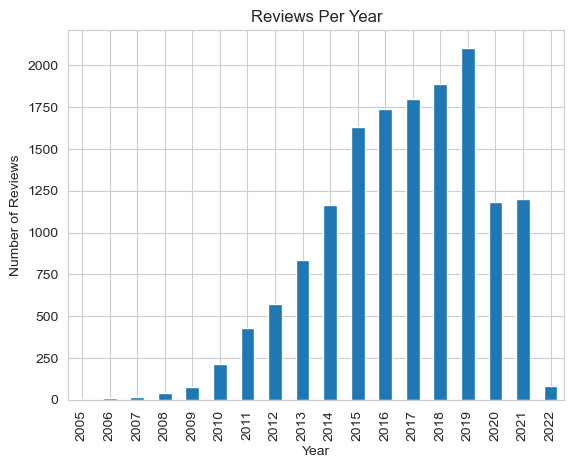

In [43]:
# Temporary year extraction to visualize the volume of reviews across different years
plt.figure()
pd.to_datetime(df["date"]).dt.year.value_counts().sort_index().plot(kind="bar")
plt.title("Reviews Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()

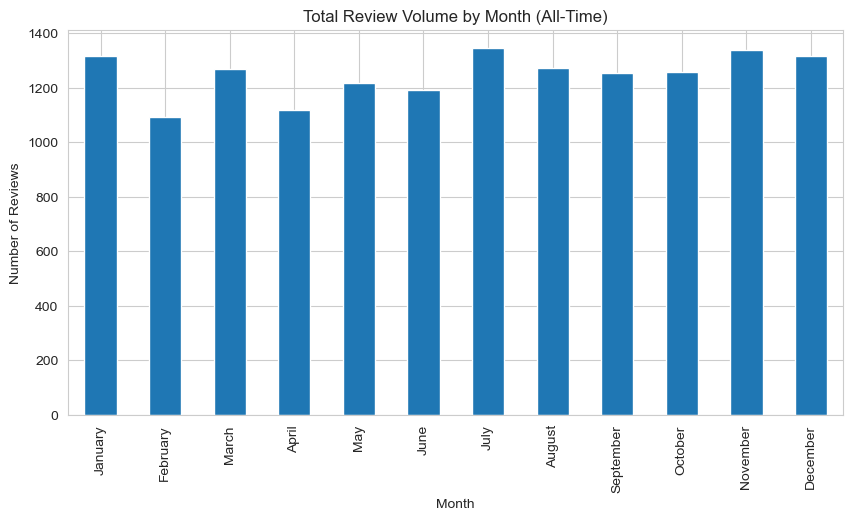

In [44]:
# Checking total review volume month-to-month across the entire dataset
plt.figure(figsize=(10,5))
# Extracting month name and ordering them correctly
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Temporary month extraction to visualize all-time monthly review volume
pd.to_datetime(df["date"]).dt.month_name().value_counts().reindex(month_order).plot(kind="bar")
plt.title("Total Review Volume by Month (All-Time)")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.show()